In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
import kagglehub

# Download latest version
# Note: This will download the dataset to a specific location in your Colab environment.
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
Path to dataset files: /kaggle/input/superstore-dataset-final


In [4]:
# The dataset might be within a subfolder inside the downloaded path.
# Let's assume the CSV file is named 'Sample - Superstore.csv' and is directly in the downloaded 'path' for now.
# If it's in a subfolder, we might need to adjust this path.
# For example, if it's in a folder named 'superstore-dataset-final' within the downloaded path, it would be:
# file_path = f"{path}/superstore-dataset-final/Sample - Superstore.csv"

# For now, let's assume it's directly under the path or we can find it.
import os

# Look for the CSV file within the downloaded directory
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if not csv_files:
    raise FileNotFoundError("No CSV file found in the downloaded Kaggle dataset.")

# Assuming 'Sample - Superstore.csv' is the one we want if multiple exist
# Or just pick the first one if there's only one.
if 'Sample - Superstore.csv' in csv_files:
    file_name = 'Sample - Superstore.csv'
else:
    print(f"'Sample - Superstore.csv' not found directly. Using the first found CSV: {csv_files[0]}")
    file_name = csv_files[0]

df_file_path = os.path.join(path, file_name)
print(f"Using dataset file: {df_file_path}")

Using dataset file: /kaggle/input/superstore-dataset-final/Sample - Superstore.csv


In [28]:
df = pd.read_csv(df_file_path, encoding='latin1')

print("Dataset Shape:")
df.shape

Dataset Shape:


(9994, 21)

In [29]:
print("\nDataset Data Types:")
df.dtypes


Dataset Data Types:


,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [30]:
print("\nDataset Description (numerical):")
df.describe()


Dataset Description (numerical):


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [10]:
# Step 3: Select numerical features
# Based on the prompt's example, these seem to be the intended numerical predictors.
# Assuming 'Sales' is the target variable and is also numerical.
features = ['Quantity', 'Discount', 'Profit']

print("\nSelected Numerical Predictors:", features)


Selected Numerical Predictors: ['Quantity', 'Discount', 'Profit']


In [11]:
# Step 4: Check for missing values
print("\nMissing values in selected features and Sales:")
print(df[features + ['Sales']].isnull().sum())


Missing values in selected features and Sales:
Quantity    0
Discount    0
Profit      0
Sales       0
dtype: int64


In [31]:

# Step 5: Create a correlation matrix
import seaborn as sns

print("\nCorrelation Matrix:")
corr = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()
corr


Correlation Matrix:


,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


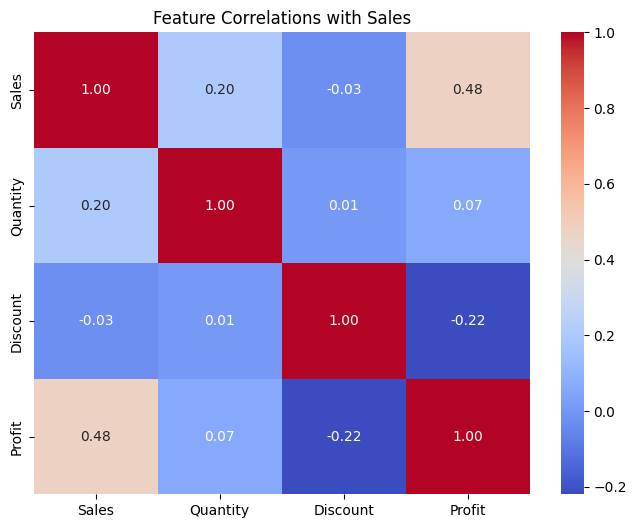

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlations with Sales')
plt.show()

In [15]:
# Define X (features) and y (Sales):
X = df[['Quantity', 'Discount', 'Profit']]
y = df['Sales']

In [16]:
# Split data:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# Fit the model:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [20]:
# Compute metrics:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.4f}")

MSE: 680377.46, RMSE: 824.85, MAE: 245.08, R2: -0.1518


In [22]:
# Print coefficients and intercept:
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {model.intercept_:.4f}")


Model Coefficients:
Quantity: 41.5503
Discount: 249.5718
Profit: 1.5617
Intercept: -18.0971


In [32]:
# Step 1: Create polynomial features (degree 2)
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print("\nShape of X_train_poly:", X_train_poly.shape)
print("Shape of X_test_poly:", X_test_poly.shape)


Shape of X_train_poly: (7995, 9)
Shape of X_test_poly: (1999, 9)


In [33]:

# Step 2: Train a new linear regression on the polynomial features
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)
y_pred_poly = model_poly.predict(X_test_poly)

# Step 3: Compute the same metrics (MSE, RMSE, MAE, R2). Compare to the linear model.
print("\n--- Polynomial Regression Model Metrics ---")
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"MSE (Polynomial): {mse_poly:.2f}")
print(f"RMSE (Polynomial): {rmse_poly:.2f}")
print(f"MAE (Polynomial): {mae_poly:.2f}")
print(f"R2 (Polynomial): {r2_poly:.4f}")

print("\n--- Simple Linear Regression Model Metrics (for comparison) ---")
print(f"MSE (Linear): {mse:.2f}")
print(f"RMSE (Linear): {rmse:.2f}")
print(f"MAE (Linear): {mae:.2f}")
print(f"R2 (Linear): {r2:.4f}")


--- Polynomial Regression Model Metrics ---
MSE (Polynomial): 473873.85
RMSE (Polynomial): 688.38
MAE (Polynomial): 190.56
R2 (Polynomial): 0.1978

--- Simple Linear Regression Model Metrics (for comparison) ---
MSE (Linear): 680377.46
RMSE (Linear): 824.85
MAE (Linear): 245.08
R2 (Linear): -0.1518


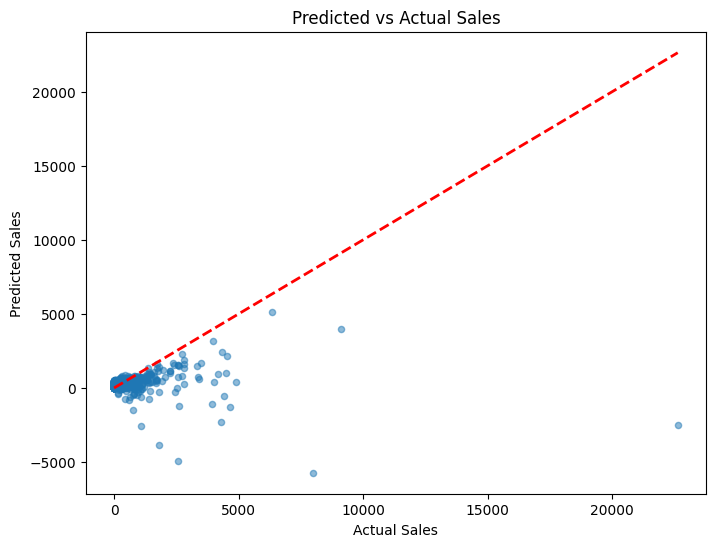

In [26]:
# Predicted vs Actual scatter plot:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Predicted vs Actual Sales')
plt.show()

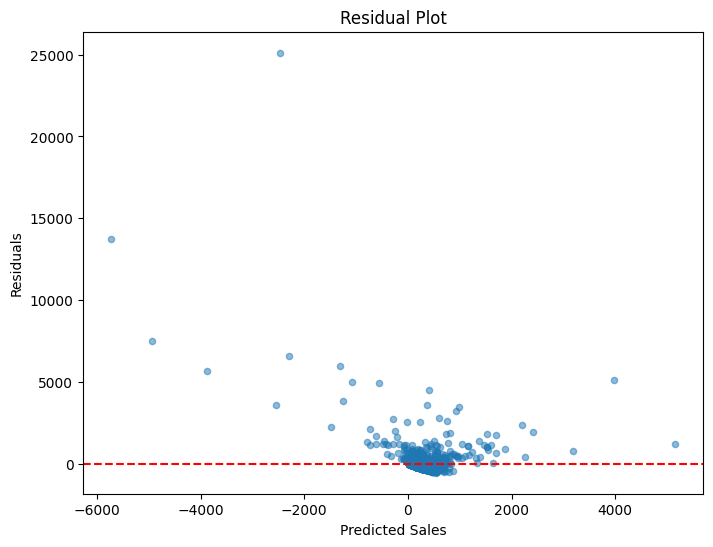

In [27]:
# Residual plot:
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5, s=20)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()